In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

class KeystrokeEncoder(nn.Module):
    def __init__(self):
        super(KeystrokeEncoder, self).__init__()
        self.conv = nn.Conv1d(in_channels=2, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.gru = nn.GRU(input_size=32, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 128)

    def forward(self, x):
        x = self.relu(self.conv(x))
        x = x.transpose(1, 2)
        _, hidden = self.gru(x)
        return self.fc(hidden[-1])

model = KeystrokeEncoder()
model.load_state_dict(torch.load('keystroke_sota_weights.pth'))
model.eval()
print("Model loaded and ready for evaluation.")

Model loaded and ready for evaluation.


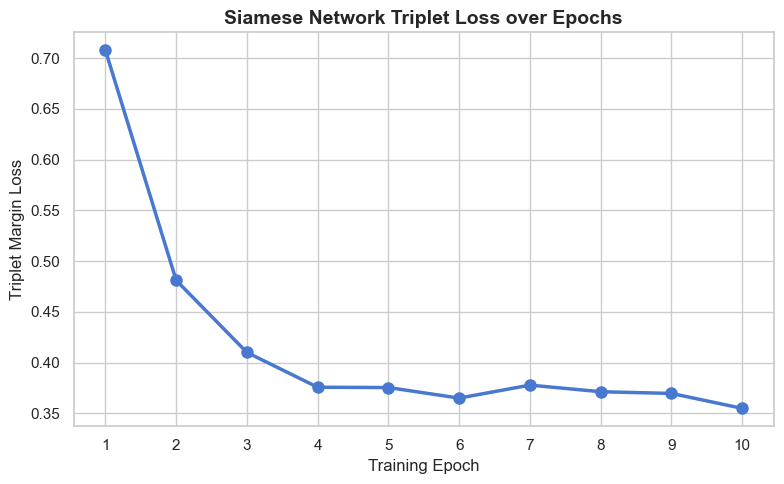

In [6]:
epochs = np.arange(1, 11)
loss_values = [0.7079, 0.4811, 0.4100, 0.3757, 0.3754, 0.3650, 0.3778, 0.3713, 0.3696, 0.3549]

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, marker='o', color='b', linewidth=2.5, markersize=8)
plt.title('Siamese Network Triplet Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Training Epoch', fontsize=12)
plt.ylabel('Triplet Margin Loss', fontsize=12)
plt.xticks(epochs)
plt.tight_layout()

plt.savefig('loss_curve.png', dpi=300)
plt.show()

In [8]:
import pandas as pd
import glob
import os
import torch
import numpy as np

data_directory = os.getenv("DATASET_PATH")

print("Loading REAL evaluation data from Aalto dataset...")

all_files = glob.glob(os.path.join(data_directory, '*_keystrokes.txt'))
eval_files = all_files[-15:]

embeddings = []
labels = []
seq_length = 20

with torch.no_grad():
    for user_idx, file_path in enumerate(eval_files):
        try:
            df = pd.read_csv(file_path, sep='\t')
            df = df.sort_values(by=['TEST_SECTION_ID', 'PRESS_TIME'])
            
            df['dwell_time'] = (df['RELEASE_TIME'] - df['PRESS_TIME']) / 1000.0
            df['flight_time'] = df.groupby('TEST_SECTION_ID')['PRESS_TIME'].diff() / 1000.0
            df['flight_time'] = df['flight_time'].fillna(0)
            df['flight_time'] = df['flight_time'].clip(upper=1.0)
            df['dwell_time'] = df['dwell_time'].clip(upper=1.0)

            dwells = df['dwell_time'].values
            flights = df['flight_time'].values
            
            for i in range(0, len(dwells) - seq_length, seq_length):
                chunk_dwells = dwells[i : i + seq_length]
                chunk_flights = flights[i : i + seq_length]
                
                if len(chunk_dwells) == seq_length:
                    chunk_tensor = torch.tensor([[np.vstack((chunk_dwells, chunk_flights))]], dtype=torch.float32)
                    
                    emb = model(chunk_tensor[0]).numpy()[0]
                    embeddings.append(emb)
                    labels.append(user_idx)
                    
        except Exception as e:
            continue

embeddings = np.array(embeddings)
labels = np.array(labels)
print(f"Extracted {len(embeddings)} REAL embeddings across {len(np.unique(labels))} users.")

Loading REAL evaluation data from Aalto dataset...


Extracted 445 REAL embeddings across 12 users.


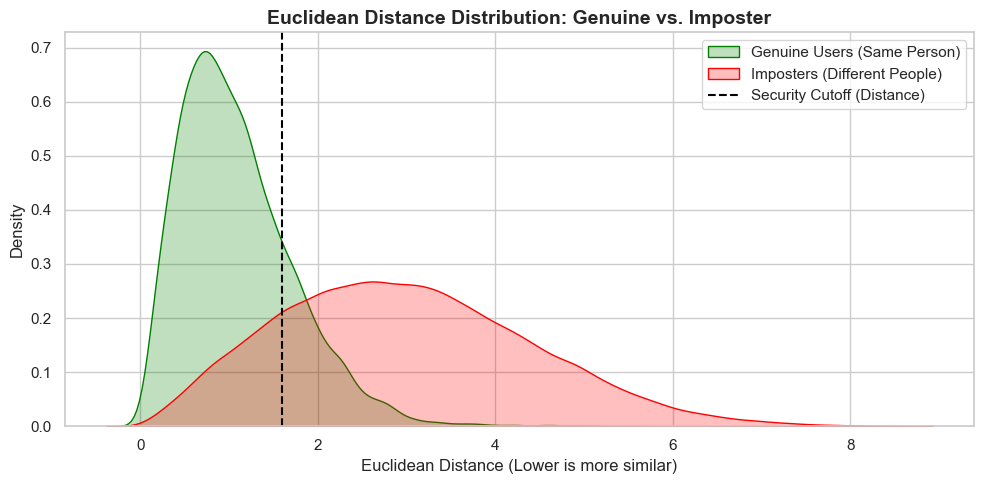

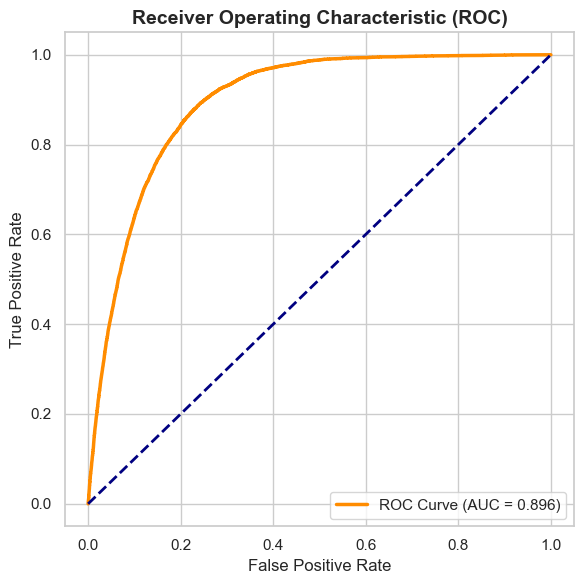

In [10]:
from scipy.spatial.distance import euclidean

genuine_dists = []
imposter_dists = []

for i in range(len(embeddings)):
    for j in range(i + 1, len(embeddings)):
        dist = euclidean(embeddings[i], embeddings[j])
        if labels[i] == labels[j]:
            genuine_dists.append(dist)
        else:
            imposter_dists.append(dist)

plt.figure(figsize=(10, 5))
sns.kdeplot(genuine_dists, fill=True, color="green", label="Genuine Users (Same Person)")
sns.kdeplot(imposter_dists, fill=True, color="red", label="Imposters (Different People)")

plt.axvline(x=1.6, color='black', linestyle='--', label='Security Cutoff (Distance)')

plt.title('Euclidean Distance Distribution: Genuine vs. Imposter', fontsize=14, fontweight='bold')
plt.xlabel('Euclidean Distance (Lower is more similar)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('distribution_histogram_l2.png', dpi=300)
plt.show()

y_true = [1]*len(genuine_dists) + [0]*len(imposter_dists)
y_scores = [-d for d in genuine_dists] + [-d for d in imposter_dists]

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve_l2.png', dpi=300)
plt.show()

Running t-SNE dimensionality reduction...


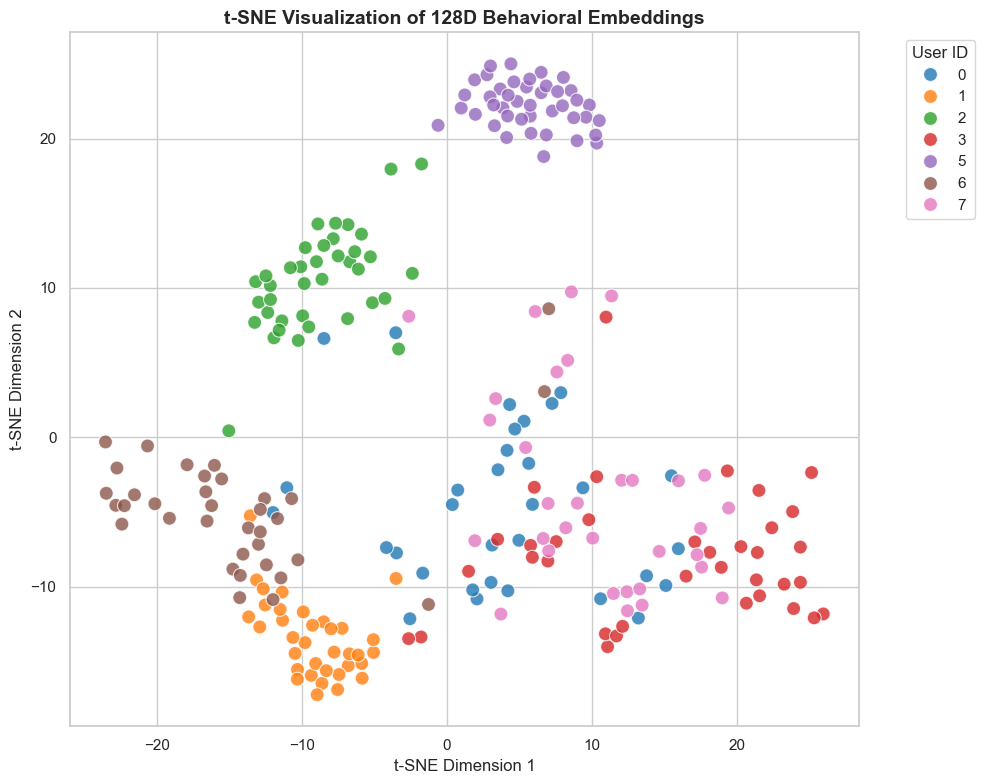

In [12]:
print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=embeddings_2d[:250, 0], 
    y=embeddings_2d[:250, 1], 
    hue=labels[:250], 
    palette="tab10", 
    s=100, 
    alpha=0.8,
    legend='full'
)

plt.title('t-SNE Visualization of 128D Behavioral Embeddings', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=300)
plt.show()